In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [39]:
df = pd.read_csv("/home/mddo/stage/M2S4/output/FY/diploid_/diploid_0/df/HFI_NI_KNN.csv")

print(df)

hits_count  reads_count  hits_count_pro   orf_len  insertion_index  \
0       0.054913     0.039589        0.162162  0.017981         0.060510   
1       0.031792     0.040972        0.270270  0.013895         0.043307   
2       0.002890     0.000173        0.000000  0.021251         0.002762   
3       0.014451     0.040280        0.081081  0.012056         0.022026   
4       0.054913     0.017893        0.081081  0.117899         0.010668   
...          ...          ...             ...       ...              ...   
6349    0.089595     0.025240        0.000000  0.079281         0.025535   
6350    0.008671     0.000432        0.000000  0.055442         0.003472   
6351    0.000000     0.000000        0.000000  0.017573         0.000000   
6352    0.000000     0.000000        0.000000  0.207601         0.000000   
6353    0.000000     0.000000        0.000000  0.029424         0.000000   

            NI  NI_ratio       HFI  HFI_ratio        orf    label  
0     2.806597  0.853567 

label  number of genes
0  non_ess             5435
1      ess              919


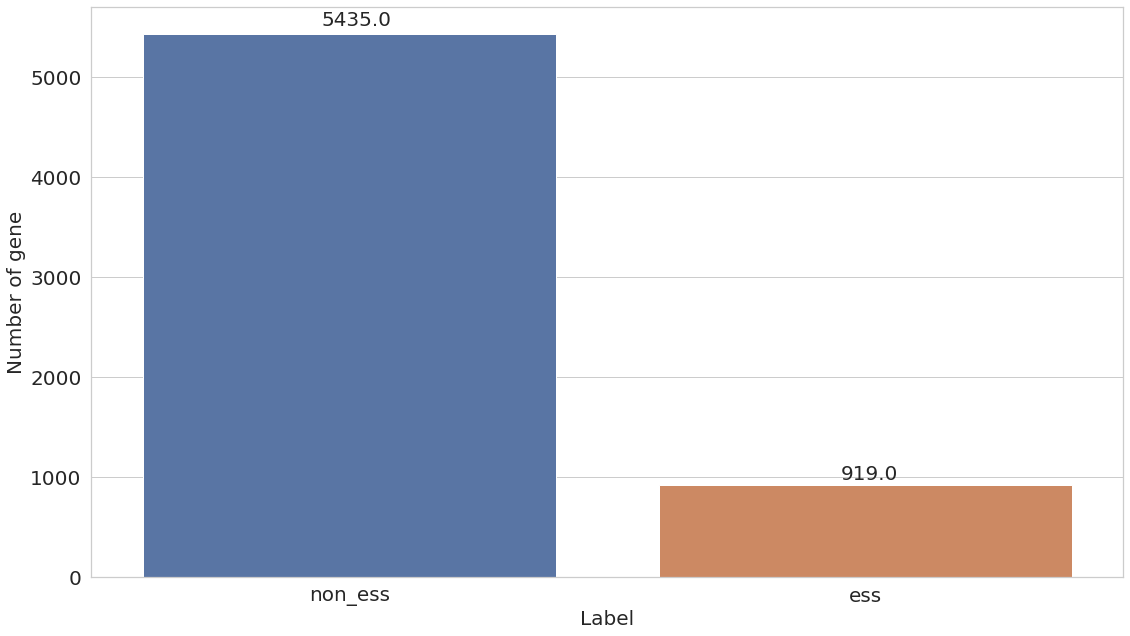

In [40]:
data_gene_count = df['label'].value_counts()
data_gene_count = pd.DataFrame(data_gene_count)
data_gene_count = data_gene_count.reset_index()
data_gene_count.columns = ["label","number of genes"]
print(data_gene_count)

sns.set(style="whitegrid")
#tips = sns.load_dataset("tips")
ax = sns.barplot(y = "number of genes", x = "label", data = data_gene_count, ci="sd")
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005),size=20, 
                xytext=(180, 2),  # 3 points vertical offset
                textcoords="offset points", va='bottom')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.xlabel("Label",size = 20)
plt.ylabel("Number of gene",size = 20)
plt.xticks(size = 20)
plt.yticks(size = 20)
fig.savefig('test2png.png', dpi=100)



In [41]:
X = df.drop(columns = ["label","orf"], axis = 1)
y = df['label']
print(X)
print(y)



hits_count  reads_count  hits_count_pro   orf_len  insertion_index  \
0       0.054913     0.039589        0.162162  0.017981         0.060510   
1       0.031792     0.040972        0.270270  0.013895         0.043307   
2       0.002890     0.000173        0.000000  0.021251         0.002762   
3       0.014451     0.040280        0.081081  0.012056         0.022026   
4       0.054913     0.017893        0.081081  0.117899         0.010668   
...          ...          ...             ...       ...              ...   
6349    0.089595     0.025240        0.000000  0.079281         0.025535   
6350    0.008671     0.000432        0.000000  0.055442         0.003472   
6351    0.000000     0.000000        0.000000  0.017573         0.000000   
6352    0.000000     0.000000        0.000000  0.207601         0.000000   
6353    0.000000     0.000000        0.000000  0.029424         0.000000   

            NI  NI_ratio       HFI  HFI_ratio  
0     2.806597  0.853567  0.168790   1.232558

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=1)

In [44]:
x = random_forest.fit(X_train, y_train)
print(x)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=10, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=None, oob_score=False, random_state=1, verbose=0,
                       warm_start=False)


In [45]:
from sklearn.metrics import accuracy_score
y_predict = random_forest.predict(X_test)
accuracy_score(y_test, y_predict)

0.8986784140969163

Feature ranking:
1. feature 4 (0.188855)
2. feature 8 (0.176441)
3. feature 6 (0.144406)
4. feature 5 (0.130367)
5. feature 3 (0.108495)
6. feature 2 (0.088626)
7. feature 1 (0.063001)
8. feature 7 (0.061877)
9. feature 0 (0.037934)


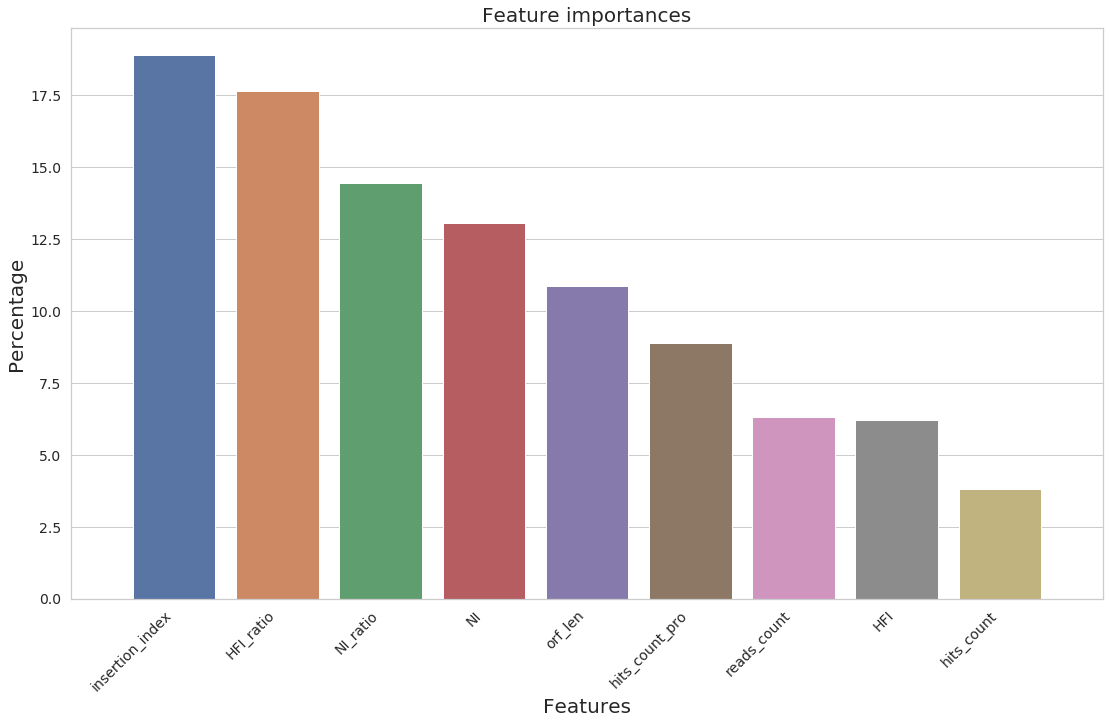

In [46]:
importances = random_forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in random_forest.estimators_],
             axis=0)
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

col_feats = []
for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))
    col_feats.append([X.columns[indices[f]],importances[indices[f]]*100])

ft_importances = pd.DataFrame(col_feats)
ft_importances.columns = ["Feature","percentage"]

# Plot the feature importances of the forest
plt.figure()
plt.title("Feature importances", size = 20)
sns.barplot(x = "Feature", y = "percentage", data = ft_importances)
#plt.bar(range(X.shape[1]), importances[indices],
#       color="r", yerr=std[indices], align="center")
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Features", size = 20)
plt.ylabel("Percentage", size = 20)
plt.xticks(rotation=45, ha='right')
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(18.5, 10.5)
plt.show()